
# Linear Models I & II – Lecture Notebook

This notebook connects **Week I (linear regression + loss + gradient descent)** to **Week II (logistic regression + classification + regularization)**.

We will use **two datasets**:

- **Diabetes (sklearn)**: continuous outcome → *linear regression*
- **Iris (sklearn)**: 3-class outcome → *multinomial logistic regression*

Goals:
1. Fit linear regression, visualize loss (L2) meaningfully
2. Show **Gradient Descent (GD)** vs **Stochastic GD (SGD)** behavior
3. Fit multiclass logistic regression and compute **logistic loss (cross-entropy)**
4. Show how **L1 regularization** can drive some feature weights to **exactly zero**
5. Visualize **decision boundaries** for logistic regression (2D slice)

> Tip: Run cells top-to-bottom. Randomness in SGD is controlled with a fixed seed for reproducibility.


## 0. Setup

In [22]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler, OneHotEncoder

SEED = 2026
np.random.seed(SEED)



## Using Linear Regression for Classification

Now we switch to classification.

We use the **Iris** dataset:
- **Target**: 3 flower species (3 classes)
- **Features**: 4 measurements

To visualize decision boundaries, we use **two features** (2D).


In [23]:

iris = datasets.load_iris()
X_iris_raw = iris.data
y_iris = iris.target
iris_feature_names = iris.feature_names
iris_target_names = iris.target_names

print("Dataset: Iris")
print("Features:", iris_feature_names)
print("Target classes:", list(iris_target_names))
print("X shape:", X_iris_raw.shape, "y shape:", y_iris.shape)


Dataset: Iris
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
X shape: (150, 4) y shape: (150,)


### Data Preprocessing

We conduct the following data preprocessing:
- We first transform features to `DataFrame`.
- Since our target is 3 classes (0, 1, 2) for each flower we need to employ one-hot-encoding.
- After the encoding we transform the target into a DataFrame as well.

In [24]:
X = pd.DataFrame(iris.data, columns=iris_feature_names)
enc = OneHotEncoder(sparse_output=False)
encoded = enc.fit_transform(iris.target.reshape(-1, 1))
colnames = ["cat_" + c for c in iris_target_names]
Y = pd.DataFrame(encoded, columns=colnames)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
Y.head()

,cat_setosa,cat_versicolor,cat_virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


Not that values in Y_hat are not probabilities.

In [26]:
iris.frame

In [27]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X, Y)

Y_hat = lr.predict(X)

y_hat = np.argmax(Y_hat, axis=1)

mse = np.mean((y_hat - iris.target)**2)
print(f"MSE = {mse:.3f}")

MSE = 0.153


In [28]:
lr.score(X, Y)

0.5959494125207327

## Using Logistic Regression

In [ ]:
lr = LogisticRegression()

In [ ]:

# Use 2 features for 2D decision boundary visualization
f1, f2 = 0, 2  # sepal length & petal length
X2_raw = X_iris_raw[:, [f1, f2]]

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2_raw)

print("Using 2D features for visualization:")
print(f"  Feature 1: {iris_feature_names[f1]}")
print(f"  Feature 2: {iris_feature_names[f2]}")


Using 2D features for visualization:
  Feature 1: sepal length (cm)
  Feature 2: petal length (cm)



### Fit Multinomial Logistic Regression + Logistic Loss

We evaluate training loss using **cross-entropy** (log loss).


In [ ]:

log_reg = LogisticRegression(solver="lbfgs", max_iter=200)
log_reg.fit(X2, y_iris)

y_prob = log_reg.predict_proba(X2)
print("Training log loss (cross-entropy):", log_loss(y_iris, y_prob))


Training log loss (cross-entropy): 0.23629296358193017


## 5. Decision Boundaries (2D)

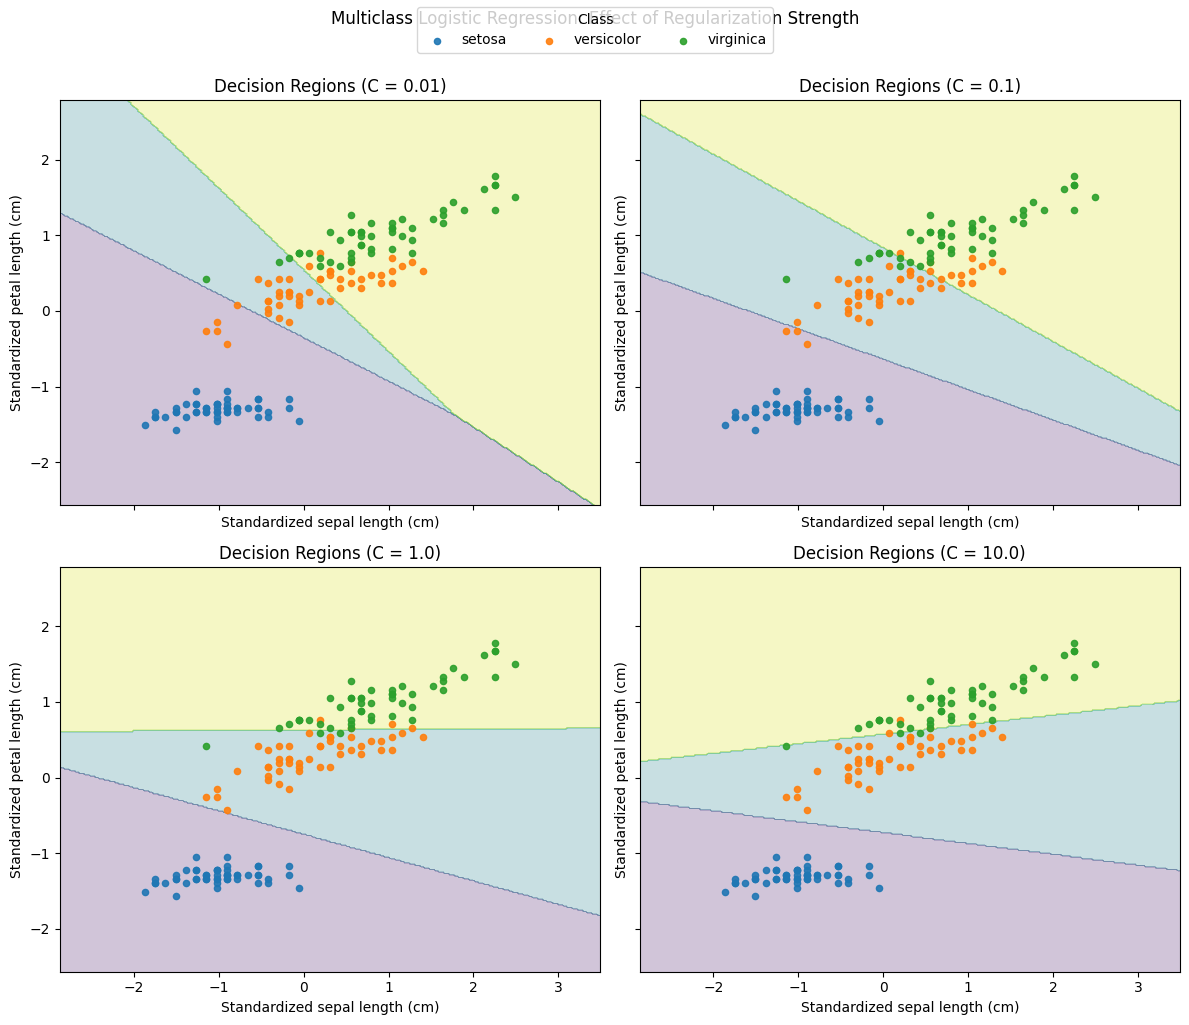

In [ ]:
# ----- assumes you already have: X2, y_iris, iris_target_names, iris_feature_names, f1, f2 -----

# Mesh grid for decision regions
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Different regularization strengths to compare
C_values = [0.01, 0.1, 1.0, 10.0]  # small C = strong reg, large C = weak reg

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, C in zip(axes, C_values):
    model = LogisticRegression(
        solver="lbfgs",
        C=C,
        max_iter=500
    )
    model.fit(X2, y_iris)

    Z = model.predict(grid).reshape(xx.shape)

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Points per class (legend handled once later)
    for cls, name in enumerate(iris_target_names):
        mask = (y_iris == cls)
        ax.scatter(X2[mask, 0], X2[mask, 1], label=name, alpha=0.9, s=20)

    ax.set_title(f"Decision Regions (C = {C})")
    ax.set_xlabel(f"Standardized {iris_feature_names[f1]}")
    ax.set_ylabel(f"Standardized {iris_feature_names[f2]}")

# Build one shared legend (avoid duplicates)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Class", loc="upper center", ncol=len(iris_target_names))

fig.suptitle("Multiclass Logistic Regression: Effect of Regularization Strength", y=1.02)
plt.tight_layout()
plt.show()



## 6. L1 Regularization → Feature Selection (Concept in Code)

We now use **all 4 Iris features** and fit multinomial logistic regression with **L1 penalty**.

In sklearn, **smaller `C`** means **stronger regularization** (roughly, `C = 1/λ`).


In [ ]:

X_full = StandardScaler().fit_transform(X_iris_raw)

log_reg_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.08,
    max_iter=5000,
    random_state=42
)
log_reg_l1.fit(X_full, y_iris)

coef = log_reg_l1.coef_  # (n_classes, n_features)

print("L1-regularized coefficients (rows=classes, cols=features):")
for c_idx, c_name in enumerate(iris_target_names):
    row = ", ".join([f"{iris_feature_names[j]}={coef[c_idx, j]: .4f}" for j in range(coef.shape[1])])
    print(f"  Class {c_name}: {row}")

# Identify effectively-dropped features: coefficient ~ 0 for ALL classes
eps = 1e-4
dropped = np.all(np.abs(coef) < eps, axis=0)

print("\nEffectively dropped features (all-class |coef| < 1e-4):")
for j, name in enumerate(iris_feature_names):
    print(f"  {name}: {'DROPPED' if dropped[j] else 'kept'}")


L1-regularized coefficients (rows=classes, cols=features):
  Class setosa: sepal length (cm)= 0.0000, sepal width (cm)= 0.0000, petal length (cm)=-1.8315, petal width (cm)= 0.0000
  Class versicolor: sepal length (cm)= 0.0000, sepal width (cm)=-0.2173, petal length (cm)= 0.0000, petal width (cm)= 0.0000
  Class virginica: sepal length (cm)= 0.0000, sepal width (cm)= 0.0000, petal length (cm)= 0.0000, petal width (cm)= 1.4645

Effectively dropped features (all-class |coef| < 1e-4):
  sepal length (cm): DROPPED
  sepal width (cm): kept
  petal length (cm): kept
  petal width (cm): kept



### Optional: Compare Against No Regularization

This shows how coefficients change when we remove the penalty.


In [ ]:

log_reg_none = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=500
)
log_reg_none.fit(X_full, y_iris)

coef_none = log_reg_none.coef_

print("No-regularization coefficients (rows=classes, cols=features):")
for c_idx, c_name in enumerate(iris_target_names):
    row = ", ".join([f"{iris_feature_names[j]}={coef_none[c_idx, j]: .4f}" for j in range(coef_none.shape[1])])
    print(f"  Class {c_name}: {row}")


No-regularization coefficients (rows=classes, cols=features):
  Class setosa: sepal length (cm)=-5.4954, sepal width (cm)= 4.0061, petal length (cm)=-9.0337, petal width (cm)=-8.2037
  Class versicolor: sepal length (cm)= 3.7596, sepal width (cm)=-0.5440, petal length (cm)=-3.8115, petal width (cm)=-2.8863
  Class virginica: sepal length (cm)= 1.7358, sepal width (cm)=-3.4621, petal length (cm)= 12.8452, petal width (cm)= 11.0900



## Summary

- **Linear regression**: predicts continuous targets, minimizes **L2 loss**
- **Loss surfaces** show how optimization behaves in parameter space
- **GD vs SGD**: GD is smoother; SGD is noisier but can be faster per step
- **Logistic regression**: predicts class probabilities; minimizes **cross-entropy (log loss)**
- **Decision boundaries** in logistic regression are **linear** in the chosen feature space
- **L1 regularization** can force coefficients to **zero** → conceptual feature selection (LASSO-like effect)
